In [3]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


# 1. SETUP

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

# 2. CONFIG

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Sesuaikan kemampuan GPU

TRAIN_DIR = "data/processed/train"
VAL_DIR   = "data/processed/validation"
TEST_DIR  = "data/processed/test"

EPOCHS = 30 # Bisa diubah
FINE_TUNE_EPOCHS = 15 # Epoch untuk fine-tuning

INITIAL_LR = 1e-4 # Learning rate di 0.0001
FINE_TUNE_LR = 1e-5 # Learning rate di 0.00001 untuk fine-tuning

# Kontrol training: default jalankan full epoch (tanpa stop otomatis)
USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 7
EARLY_STOP_START_EPOCH = 3

# 3. LOAD DATASET

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalisasi dataset ke rentang [0, 1] sebelum masuk ke model
train_gen = ImageDataGenerator(rescale=1.0 / 255.0)
val_test_gen = ImageDataGenerator(rescale=1.0 / 255.0)

# Membuat generator untuk data train
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data validasi
val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data test
test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1260 images belonging to 4 classes.
Found 135 images belonging to 4 classes.
Found 135 images belonging to 4 classes.


# 4. CALLBACK

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("models/best_model.h5", save_best_only=True),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

# EarlyStopping opsional: aktifkan jika ingin hentikan training otomatis
if USE_EARLY_STOPPING:
    callbacks.append(
        EarlyStopping(
            monitor='val_loss',
            patience=EARLY_STOP_PATIENCE,
            start_from_epoch=EARLY_STOP_START_EPOCH,
            restore_best_weights=True,
            verbose=1,
        )
    )

# 5. FUNCTION EVALUASI

In [8]:
def _collect_full_test_set(generator):
    generator.reset()
    x_batches, y_batches = [], []
    for _ in range(len(generator)):
        x_batch, y_batch = next(generator)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis=0)
    y_true = np.argmax(np.concatenate(y_batches, axis=0), axis=1)
    return x_test, y_true

def evaluate_model(model, model_name, return_details=False, show_plot=True):
    print(f"\n=== {model_name} ===")

    # Evaluasi loss/akurasi pada test generator
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose=0)
    print("Accuracy:", acc)
    print("Loss:", loss)

    # Prediksi menggunakan array penuh agar bentuk tensor konsisten
    x_test, y_true = _collect_full_test_set(test_data)
    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    class_names = [
        name
        for name, _ in sorted(test_data.class_indices.items(), key=lambda item: item[1])
    ]

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    print("\nClassification Report:")
    print(report_text)

    cm = confusion_matrix(y_true, y_pred)
    if show_plot:
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    if return_details:
        return {
            "model_name": model_name,
            "accuracy": float(acc),
            "loss": float(loss),
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "class_names": class_names,
            "report_dict": report_dict,
            "confusion_matrix": cm,
        }

    return acc

# 6. MODEL

## A. MobileNetV2

In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Membangun MobileNetV2 sebagai base model
def build_mobilenet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    # Data sudah dinormalisasi [0, 1], kembalikan ke [0, 255] sebelum preprocess_input
    x = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)

    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## B. EfficientNetB0

In [10]:
from tensorflow.keras.applications import EfficientNetB0

# Membangun EfficientNetB0 sebagai base model
def build_efficientnet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    x = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## C. Hybrid (Feature Fusion)

In [11]:
def build_fusion():
    input_layer = tf.keras.Input(shape=(224, 224, 3))

    # Dataset sudah [0,1], ubah dulu ke [0,255] agar preprocessing backbone sesuai
    mob_in = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)
    eff_in = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)
    base2 = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=eff_in)

    base1.trainable = False
    base2.trainable = False

    x1 = layers.GlobalAveragePooling2D()(base1.output)
    x1 = layers.BatchNormalization()(x1)

    x2 = layers.GlobalAveragePooling2D()(base2.output)
    x2 = layers.BatchNormalization()(x2)

    fusion = layers.concatenate([x1, x2])

    x = layers.Dense(256, activation='relu')(fusion)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base1, base2

# 7. Training Function (2 Tahap)

In [12]:
import time

def train_model(model, base_model=None):
    # Tahap 1
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    stage1_start = time.perf_counter()
    history_stage1 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    stage1_time = time.perf_counter() - stage1_start

    # Tahap 2 (Fine-tuning)
    if base_model is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-80]:
            layer.trainable = False
        for layer in base_model.layers[-80:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    stage2_start = time.perf_counter()
    history_stage2 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks
    )
    stage2_time = time.perf_counter() - stage2_start

    history_bundle = {
        "stage1": history_stage1.history,
        "stage2": history_stage2.history,
    }
    timing_bundle = {
        "stage1_sec": stage1_time,
        "stage2_sec": stage2_time,
        "total_sec": stage1_time + stage2_time,
    }

    return model, history_bundle, timing_bundle

# 8. Train & Evaluasi Model

## A. MobileNetV2

C:\Users\rifqi\AppData\Local\Temp\ipykernel_10680\528472138.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.3180 - loss: 2.0692

40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 681ms/step - accuracy: 0.3452 - loss: 1.8961 - val_accuracy: 0.4889 - val_loss: 1.1720 - learning_rate: 1.0000e-04
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.4488 - loss: 1.4877

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 274ms/step - accuracy: 0.4698 - loss: 1.4220 - val_accuracy: 0.6000 - val_loss: 0.9867 - learning_rate: 1.0000e-04
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.5471 - loss: 1.1917

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 271ms/step - accuracy: 0.5651 - loss: 1.1582 - val_accuracy: 0.6000 - val_loss: 0.8767 - learning_rate: 1.0000e-04
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.6162 - loss: 1.0259

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 279ms/step - accuracy: 0.8944 - loss: 0.2768 - val_accuracy: 0.7704 - val_loss: 0.5864 - learning_rate: 1.0000e-04
Epoch 25/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9154 - loss: 0.2427

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 276ms/step - accuracy: 0.9048 - loss: 0.2604 - val_accuracy: 0.7704 - val_loss: 0.5834 - learning_rate: 1.0000e-04
Epoch 26/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9207 - loss: 0.2472

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 276ms/step - accuracy: 0.9016 - loss: 0.2762 - val_accuracy: 0.7778 - val_loss: 0.5832 - learning_rate: 1.0000e-04
Epoch 27/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 270ms/step - accuracy: 0.9317 - loss: 0.2135 - val_accuracy: 0.7778 - val_loss: 0.5847 - learning_rate: 1.0000e-04
Epoch 28/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 270ms/step - accuracy: 0.9341 - loss: 0.2078 - val_accuracy: 0.7704 - val_loss: 0.5885 - learning_rate: 1.0000e-04
Epoch 29/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9132 - loss: 0.2372

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.9111 - loss: 0.2446 - val_accuracy: 0.7778 - val_loss: 0.5822 - learning_rate: 1.0000e-04
Epoch 30/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9263 - loss: 0.2087

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 287ms/step - accuracy: 0.9286 - loss: 0.2055 - val_accuracy: 0.7778 - val_loss: 0.5783 - learning_rate: 1.0000e-04
Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 528ms/step - accuracy: 0.6190 - loss: 1.0439 - val_accuracy: 0.7556 - val_loss: 0.6041 - learning_rate: 1.0000e-05
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 475ms/step - accuracy: 0.6929 - loss: 0.8420 - val_accuracy: 0.7630 - val_loss: 0.6699 - learning_rate: 1.0000e-05
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.7249 - loss: 0.7223
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 474ms/step - accuracy: 0.7278 - loss: 0.7171 - val_accuracy: 0.7630 - val_loss: 0.7547 - learning_rate: 1.0000e-05
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 469ms/step - accuracy: 0.7698 - loss: 0.6091 - val_accuracy: 0.7556 - val_loss: 0.8062 - learning_rate: 5.0000e-06
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 481ms/step - accuracy: 0.7746 - l

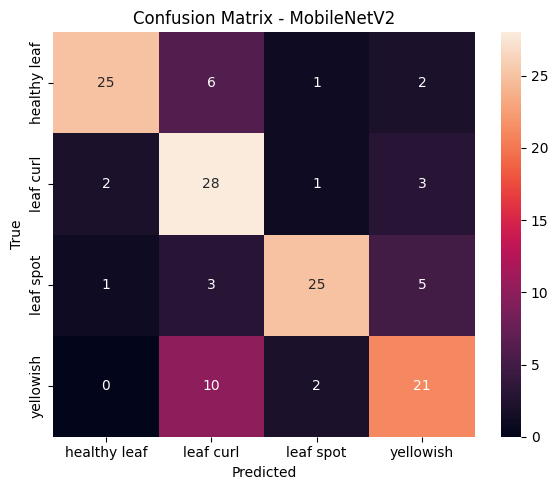

In [13]:
model_m, base_m = build_mobilenet()
model_m, history_m, timing_m = train_model(model_m, base_m)
eval_m = evaluate_model(model_m, "MobileNetV2", return_details=True)
acc_m = eval_m["accuracy"]

## B. EfficientNetB0

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 467ms/step - accuracy: 0.3421 - loss: 1.9425 - val_accuracy: 0.4074 - val_loss: 1.2671 - learning_rate: 1.0000e-04
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 391ms/step - accuracy: 0.4714 - loss: 1.4510 - val_accuracy: 0.6148 - val_loss: 1.1097 - learning_rate: 1.0000e-04
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.5156 - loss: 1.2470
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 394ms/step - accuracy: 0.5421 - loss: 1.1896 - val_accuracy: 0.6444 - val_loss: 0.9908 - learning_rate: 1.0000e-04
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 394ms/step - accuracy: 0.5905 - loss: 1.0880 - val_accuracy: 0.6741 - val_loss: 0.9268 - learning_rate: 5.0000e-05
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 396ms/step - accuracy: 0.6230 - loss: 1.0102 - val_accuracy: 0.6667 - val_loss: 0.8737 - learning_rate: 5.0000e-05
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 

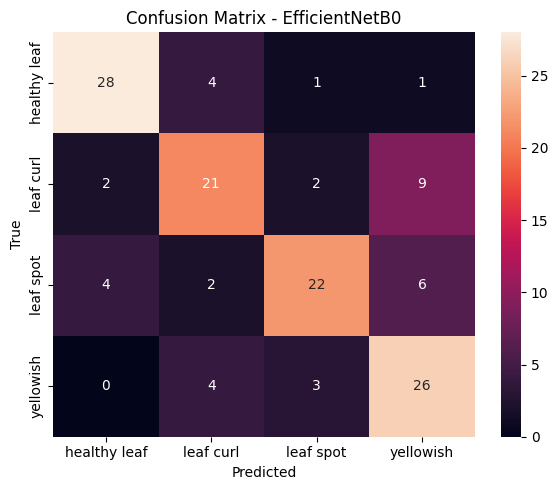

In [14]:
model_e, base_e = build_efficientnet()
model_e, history_e, timing_e = train_model(model_e, base_e)
eval_e = evaluate_model(model_e, "EfficientNetB0", return_details=True)
acc_e = eval_e["accuracy"]

## C. Hybrid Model

C:\Users\rifqi\AppData\Local\Temp\ipykernel_10680\3286220957.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)


Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 678ms/step - accuracy: 0.4429 - loss: 1.6567 - val_accuracy: 0.5926 - val_loss: 0.9731 - learning_rate: 1.0000e-04
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 597ms/step - accuracy: 0.6310 - loss: 0.9888 - val_accuracy: 0.6963 - val_loss: 0.7622 - learning_rate: 1.0000e-04
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.7343 - loss: 0.7359
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 603ms/step - accuracy: 0.7484 - loss: 0.6925 - val_accuracy: 0.7407 - val_loss: 0.6611 - learning_rate: 1.0000e-04
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 616ms/step - accuracy: 0.7810 - loss: 0.5391 - val_accuracy: 0.7704 - val_loss: 0.6071 - learning_rate: 5.0000e-05
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.7989 - loss: 0.5274

40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 623ms/step - accuracy: 0.8063 - loss: 0.5217 - val_accuracy: 0.7630 - val_loss: 0.5691 - learning_rate: 5.0000e-05
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.8435 - loss: 0.4181

40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 618ms/step - accuracy: 0.8373 - loss: 0.4385 - val_accuracy: 0.7778 - val_loss: 0.5439 - learning_rate: 5.0000e-05
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.8520 - loss: 0.3707

40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 617ms/step - accuracy: 0.8413 - loss: 0.4059 - val_accuracy: 0.7778 - val_loss: 0.5292 - learning_rate: 5.0000e-05
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.8399 - loss: 0.4393

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 686ms/step - accuracy: 0.9817 - loss: 0.0674 - val_accuracy: 0.8593 - val_loss: 0.4249 - learning_rate: 5.0000e-06
Epoch 9/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9870 - loss: 0.0583

40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 683ms/step - accuracy: 0.9913 - loss: 0.0496 - val_accuracy: 0.8519 - val_loss: 0.4217 - learning_rate: 5.0000e-06
Epoch 10/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9811 - loss: 0.0604

40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 684ms/step - accuracy: 0.9817 - loss: 0.0627 - val_accuracy: 0.8593 - val_loss: 0.4214 - learning_rate: 5.0000e-06
Epoch 11/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9878 - loss: 0.0500

40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 682ms/step - accuracy: 0.9905 - loss: 0.0429 - val_accuracy: 0.8593 - val_loss: 0.4191 - learning_rate: 5.0000e-06
Epoch 12/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 674ms/step - accuracy: 0.9881 - loss: 0.0489 - val_accuracy: 0.8593 - val_loss: 0.4251 - learning_rate: 5.0000e-06
Epoch 13/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 670ms/step - accuracy: 0.9857 - loss: 0.0526 - val_accuracy: 0.8593 - val_loss: 0.4300 - learning_rate: 5.0000e-06
Epoch 14/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.9898 - loss: 0.0519
Epoch 14: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 667ms/step - accuracy: 0.9905 - loss: 0.0496 - val_accuracy: 0.8593 - val_loss: 0.4332 - learning_rate: 5.0000e-06
Epoch 15/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 673ms/step - accuracy: 0.9921 - loss: 0.0421 - val_accuracy: 0.8593 - val_loss: 0.4337 - learning_rate: 2.5000e-06

=== Fusion Model ===
Accuracy: 0.8592592477798462
Loss: 0.42057833075


Classification Report:
              precision    recall  f1-score   support

healthy leaf       0.97      0.88      0.92        34
   leaf curl       0.88      0.85      0.87        34
   leaf spot       0.88      0.85      0.87        34
   yellowish       0.74      0.85      0.79        33

    accuracy                           0.86       135
   macro avg       0.87      0.86      0.86       135
weighted avg       0.87      0.86      0.86       135



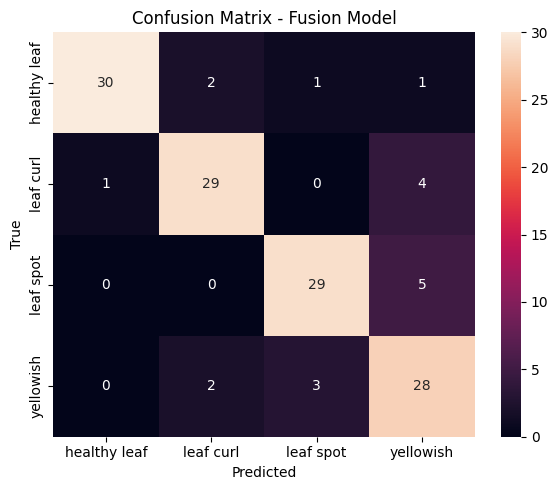

In [15]:
model_f, base1, base2 = build_fusion()

# Tahap 1
model_f.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
 )
hybrid_stage1_start = time.perf_counter()
history_f_stage1 = model_f.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
 )
hybrid_stage1_time = time.perf_counter() - hybrid_stage1_start

# Fine-tuning dua backbone
for layer in base1.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
for layer in base2.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model_f.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
 )
hybrid_stage2_start = time.perf_counter()
history_f_stage2 = model_f.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks
 )
hybrid_stage2_time = time.perf_counter() - hybrid_stage2_start

history_f = {
    "stage1": history_f_stage1.history,
    "stage2": history_f_stage2.history,
}
timing_f = {
    "stage1_sec": hybrid_stage1_time,
    "stage2_sec": hybrid_stage2_time,
    "total_sec": hybrid_stage1_time + hybrid_stage2_time,
}

eval_f = evaluate_model(model_f, "Fusion Model", return_details=True)
acc_f = eval_f["accuracy"]

# 9. Perbandingan Hasil

In [16]:
print("\n=== HASIL AKHIR ===")
print(f"MobileNetV2   : {acc_m}")
print(f"EfficientNet  : {acc_e}")
print(f"Fusion Model  : {acc_f}")


=== HASIL AKHIR ===
MobileNetV2   : 0.7333333492279053
EfficientNet  : 0.7185184955596924
Fusion Model  : 0.8592592477798462


# 10. Visualisasi Hasil dan Performa 3 Model

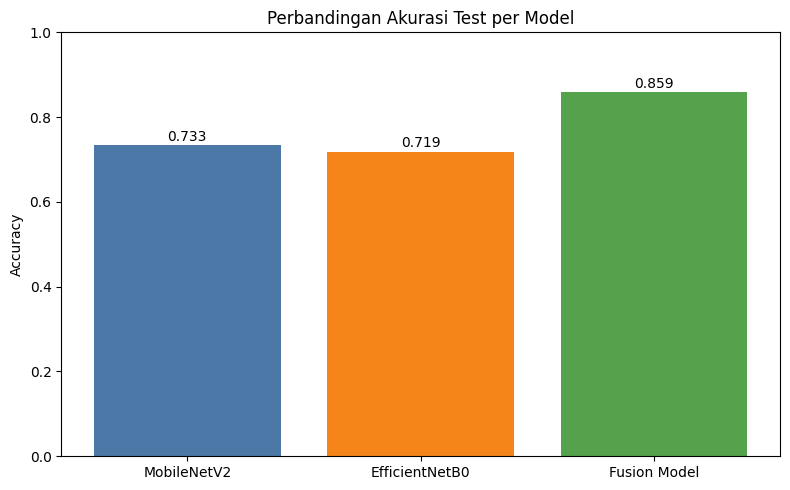

Model akurasi tertinggi: Fusion Model (0.8593)
Peningkatan Hybrid vs MobileNetV2: +12.59%


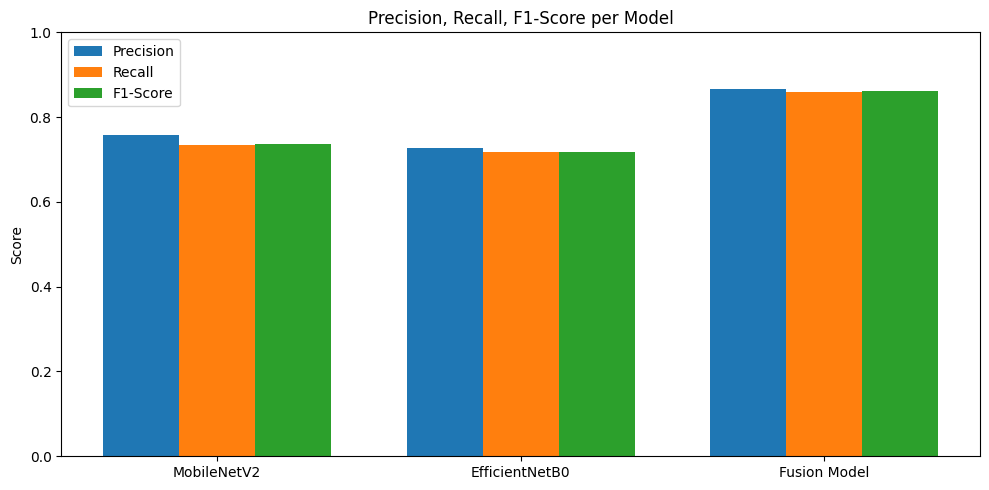

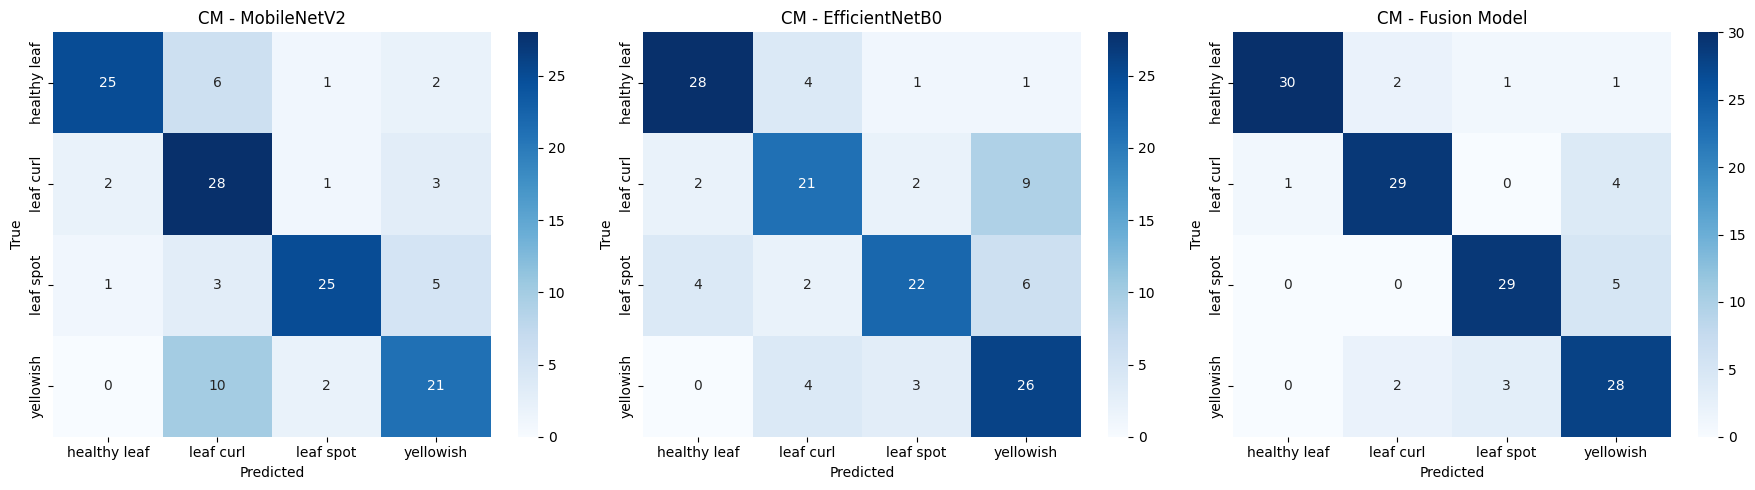

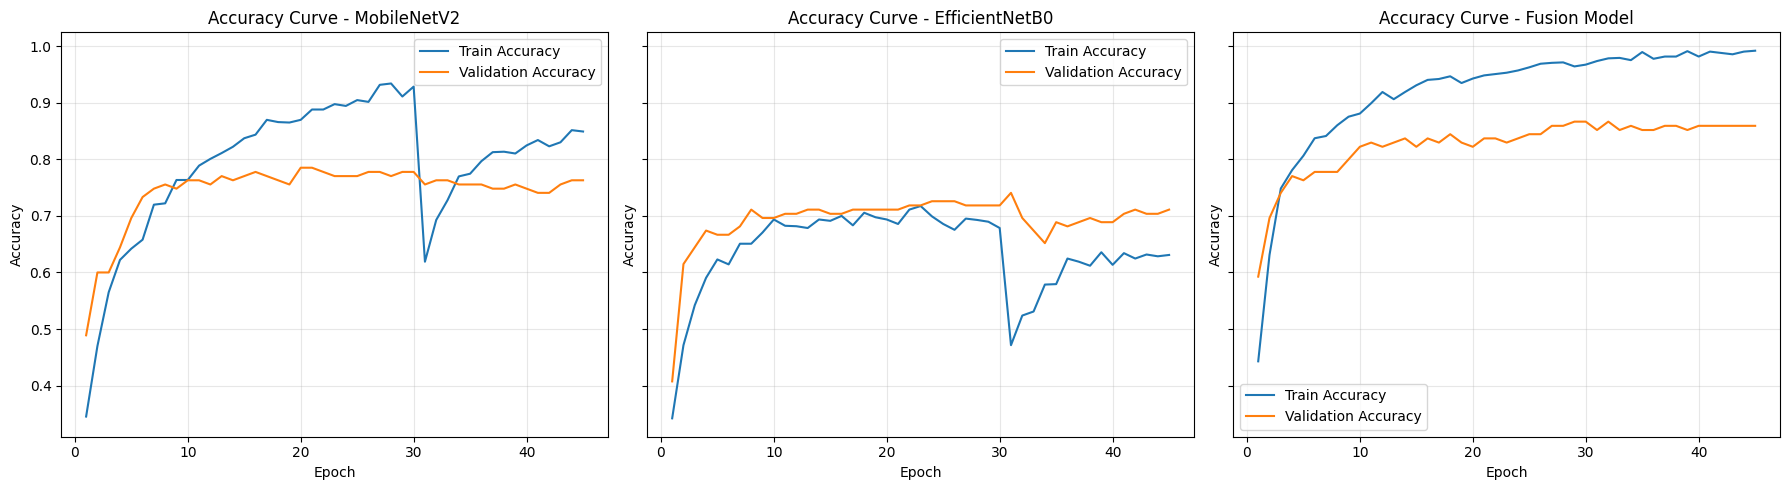

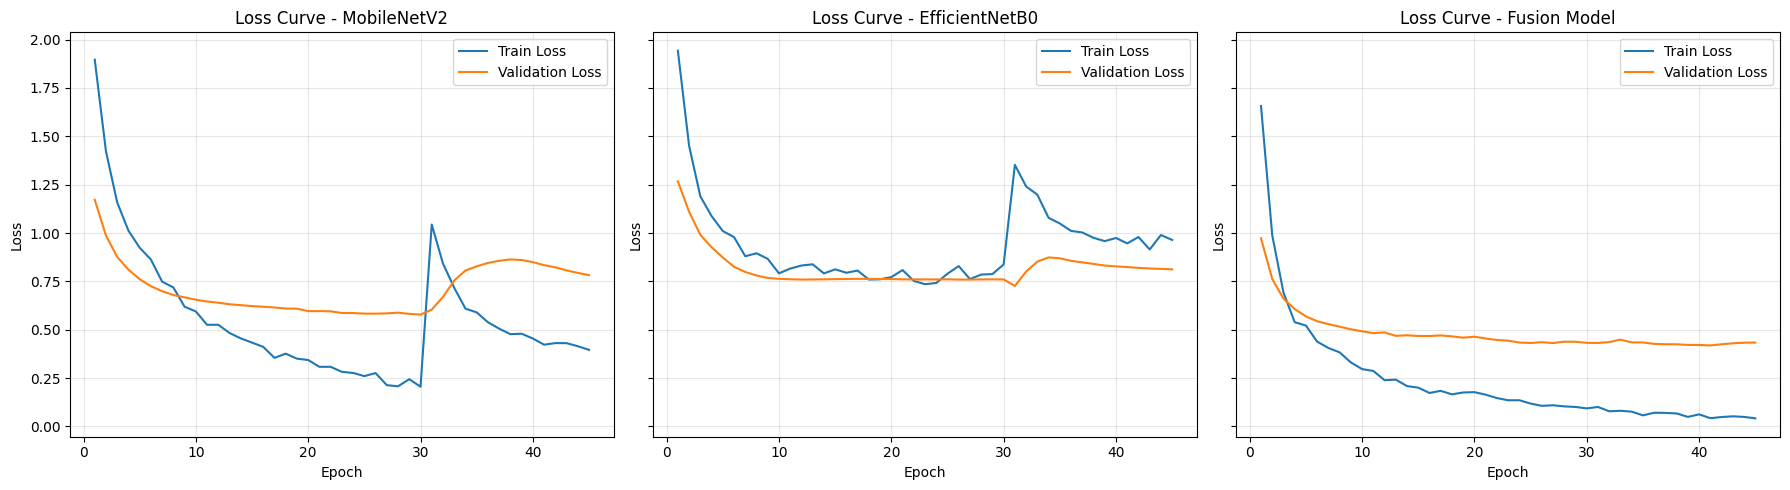

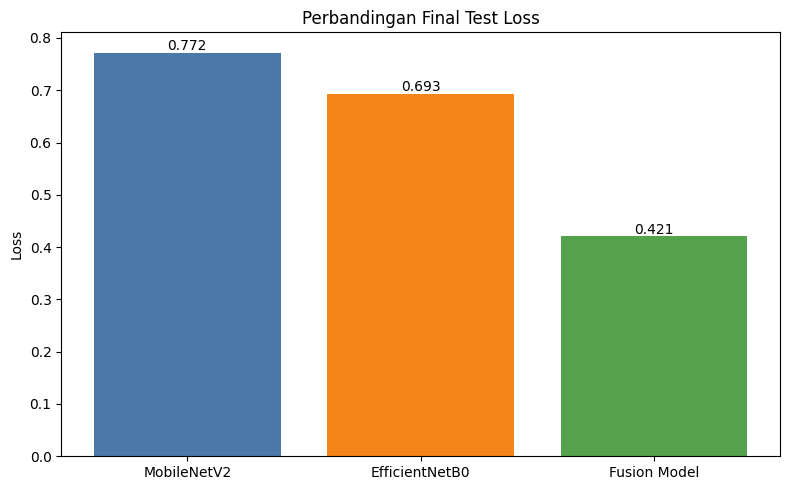

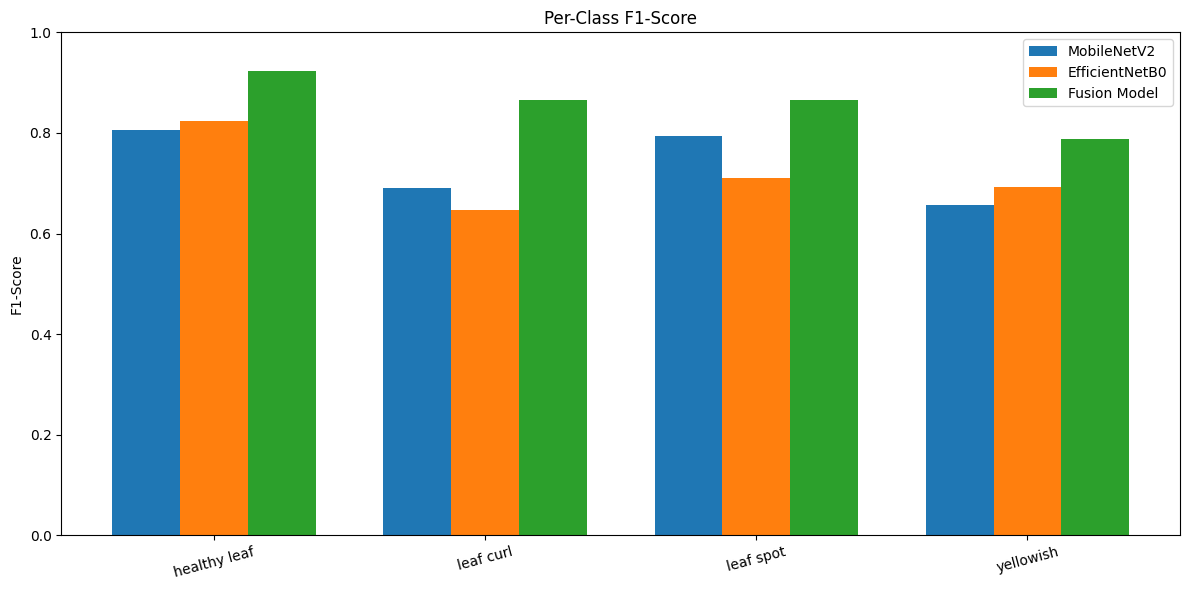

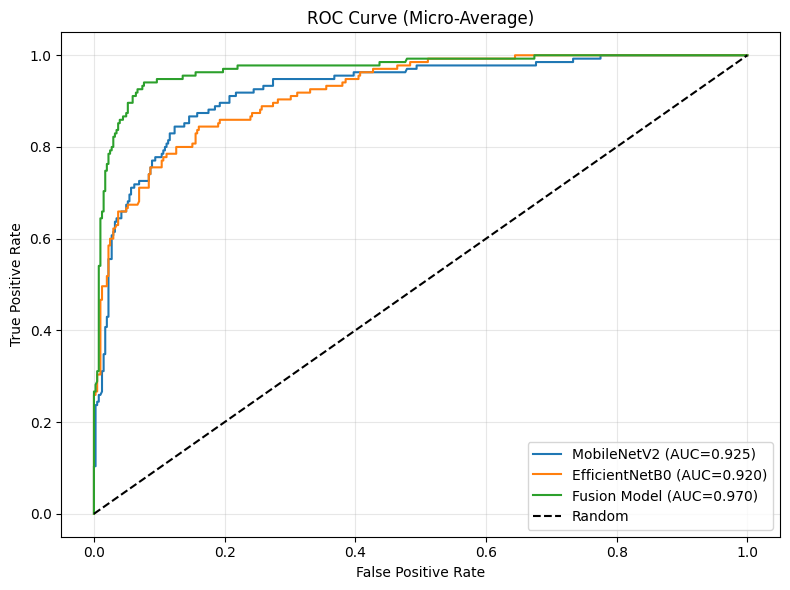

,Model,Accuracy,Precision,Recall,F1-Score,Test Loss,AUC,Training Time (sec)
2,Fusion Model,0.8593,0.8665,0.8593,0.8613,0.4206,0.9698,1173.2133
0,MobileNetV2,0.7333,0.7576,0.7333,0.7375,0.7721,0.9250,667.4475
1,EfficientNetB0,0.7185,0.7272,0.7185,0.7184,0.6930,0.9202,820.5170


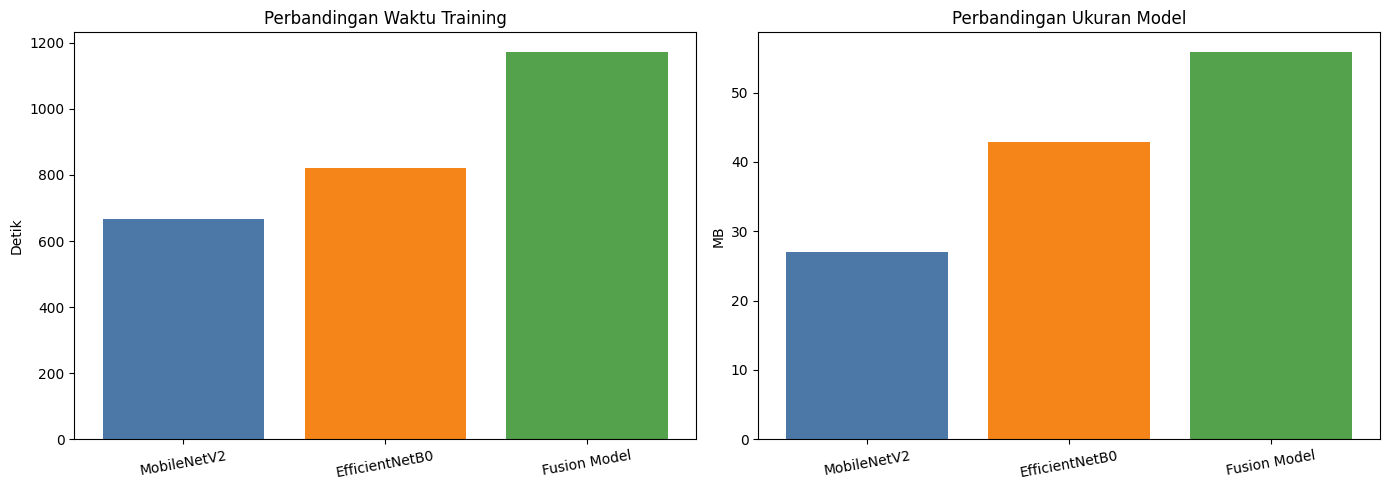


Insight cepat:
- Akurasi tertinggi: Fusion Model
- Gain Hybrid vs MobileNetV2: +12.59%
- Cek gap train vs validation untuk indikasi overfitting.
- Cek confusion matrix untuk kelas yang masih sering tertukar.


In [17]:
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

# Pastikan model tersedia di kernel
required_models = ["model_m", "model_e", "model_f"]
missing_models = [name for name in required_models if name not in globals()]
if missing_models:
    raise ValueError(
        "Model belum tersedia di kernel. Jalankan dulu cell 23, 25, dan 27. "
        f"Missing: {missing_models}"
    )

def build_eval_details(model, model_name):
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose=0)

    test_data.reset()
    x_batches, y_batches = [], []
    for _ in range(len(test_data)):
        x_batch, y_batch = next(test_data)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis=0)
    y_true = np.argmax(np.concatenate(y_batches, axis=0), axis=1)
    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    class_names_local = [
        name for name, _ in sorted(test_data.class_indices.items(), key=lambda item: item[1])
    ]

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names_local,
        zero_division=0,
        output_dict=True,
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model_name": model_name,
        "accuracy": float(acc),
        "loss": float(loss),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "class_names": class_names_local,
        "report_dict": report_dict,
        "confusion_matrix": cm,
    }

# Jika detail evaluasi belum ada, hitung otomatis
if "eval_m" not in globals():
    eval_m = build_eval_details(model_m, "MobileNetV2")
if "eval_e" not in globals():
    eval_e = build_eval_details(model_e, "EfficientNetB0")
if "eval_f" not in globals():
    eval_f = build_eval_details(model_f, "Fusion Model")

model_results = {
    "MobileNetV2": eval_m,
    "EfficientNetB0": eval_e,
    "Fusion Model": eval_f,
}

history_available = all(name in globals() for name in ["history_m", "history_e", "history_f"])
timing_available = all(name in globals() for name in ["timing_m", "timing_e", "timing_f"])

if history_available:
    model_histories = {
        "MobileNetV2": history_m,
        "EfficientNetB0": history_e,
        "Fusion Model": history_f,
    }
else:
    print("Info: history_* belum ada, grafik accuracy/loss curve tidak ditampilkan.")

if timing_available:
    model_timings = {
        "MobileNetV2": timing_m,
        "EfficientNetB0": timing_e,
        "Fusion Model": timing_f,
    }
else:
    print("Info: timing_* belum ada, perbandingan waktu training tidak ditampilkan.")

class_names = eval_m["class_names"]

def merge_history(history_bundle):
    train_acc = history_bundle["stage1"].get("accuracy", []) + history_bundle["stage2"].get("accuracy", [])
    val_acc = history_bundle["stage1"].get("val_accuracy", []) + history_bundle["stage2"].get("val_accuracy", [])
    train_loss = history_bundle["stage1"].get("loss", []) + history_bundle["stage2"].get("loss", [])
    val_loss = history_bundle["stage1"].get("val_loss", []) + history_bundle["stage2"].get("val_loss", [])
    return train_acc, val_acc, train_loss, val_loss

def get_model_size_mb(model, filename):
    model.save(filename, include_optimizer=False)
    size_mb = os.path.getsize(filename) / (1024 ** 2)
    os.remove(filename)
    return size_mb

# 1) Perbandingan Akurasi per Model
acc_df = pd.DataFrame({
    "Model": list(model_results.keys()),
    "Accuracy": [v["accuracy"] for v in model_results.values()],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.show()

best_model = acc_df.sort_values("Accuracy", ascending=False).iloc[0]
hybrid_gain_vs_mobilenet = (model_results["Fusion Model"]["accuracy"] - model_results["MobileNetV2"]["accuracy"]) * 100
print(f"Model akurasi tertinggi: {best_model['Model']} ({best_model['Accuracy']:.4f})")
print(f"Peningkatan Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")

# 2) Precision, Recall, F1-Score per Model
metric_rows = []
for model_name, result in model_results.items():
    w = result["report_dict"]["weighted avg"]
    metric_rows.append({
        "Model": model_name,
        "Precision": w["precision"],
        "Recall": w["recall"],
        "F1-Score": w["f1-score"],
    })
metrics_df = pd.DataFrame(metric_rows)

x = np.arange(len(metrics_df))
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, metrics_df["Precision"], width=w, label="Precision")
plt.bar(x, metrics_df["Recall"], width=w, label="Recall")
plt.bar(x + w, metrics_df["F1-Score"], width=w, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Confusion Matrix (3 heatmap)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, result) in zip(axes, model_results.items()):
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(f"CM - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# 4) Training vs Validation Accuracy Curve
if history_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        ax.plot(epochs, train_acc, label="Train Accuracy")
        ax.plot(epochs, val_acc, label="Validation Accuracy")
        ax.set_title(f"Accuracy Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# 5) Training vs Validation Loss Curve
if history_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        ax.plot(epochs, train_loss, label="Train Loss")
        ax.plot(epochs, val_loss, label="Validation Loss")
        ax.set_title(f"Loss Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# 6) Perbandingan Loss Akhir
loss_df = pd.DataFrame({
    "Model": list(model_results.keys()),
    "Final Test Loss": [v["loss"] for v in model_results.values()],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.show()

# 7) F1-score per Kelas (grouped)
per_class_rows = []
for model_name, result in model_results.items():
    for cls in class_names:
        per_class_rows.append({
            "Model": model_name,
            "Class": cls,
            "F1-Score": result["report_dict"][cls]["f1-score"],
        })
per_class_df = pd.DataFrame(per_class_rows)

plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

# 8) ROC Curve + AUC (micro-average multiclass)
auc_scores = {}
plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    y_prob = result["y_prob"]
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Classification Report Table (Ringkasan)
summary_rows = []
for model_name, result in model_results.items():
    w = result["report_dict"]["weighted avg"]
    summary_rows.append({
        "Model": model_name,
        "Accuracy": result["accuracy"],
        "Precision": w["precision"],
        "Recall": w["recall"],
        "F1-Score": w["f1-score"],
        "Test Loss": result["loss"],
        "AUC": auc_scores[model_name],
        "Training Time (sec)": model_timings[model_name]["total_sec"] if timing_available else np.nan,
    })
summary_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending=False)
display(summary_df.round(4))

# 10) Waktu Training dan Ukuran Model
model_sizes_mb = {
    "MobileNetV2": get_model_size_mb(model_m, "tmp_model_m.keras"),
    "EfficientNetB0": get_model_size_mb(model_e, "tmp_model_e.keras"),
    "Fusion Model": get_model_size_mb(model_f, "tmp_model_f.keras"),
}

if timing_available:
    efficiency_df = pd.DataFrame({
        "Model": list(model_timings.keys()),
        "Training Time (sec)": [v["total_sec"] for v in model_timings.values()],
        "Model Size (MB)": [model_sizes_mb[name] for name in model_timings.keys()],
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[0].set_title("Perbandingan Waktu Training")
    axes[0].set_ylabel("Detik")
    axes[0].tick_params(axis='x', rotation=10)

    axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[1].set_title("Perbandingan Ukuran Model")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.show()
else:
    size_df = pd.DataFrame({
        "Model": list(model_sizes_mb.keys()),
        "Model Size (MB)": list(model_sizes_mb.values()),
    })
    plt.figure(figsize=(8, 5))
    plt.bar(size_df["Model"], size_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Perbandingan Ukuran Model")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.show()

print("\nInsight cepat:")
print(f"- Akurasi tertinggi: {summary_df.iloc[0]['Model']}")
print(f"- Gain Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")
print("- Cek gap train vs validation untuk indikasi overfitting.")
print("- Cek confusion matrix untuk kelas yang masih sering tertukar.")

# 11. Export Grafik dan Tabel ke Folder Reports

In [18]:
from pathlib import Path

base_dir = Path.cwd()
fig_dir = base_dir / "reports" / "figures"
metrics_dir = base_dir / "reports" / "metrics"
fig_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# Simpan tabel metrik
acc_df.to_csv(metrics_dir / "accuracy_per_model.csv", index=False)
metrics_df.to_csv(metrics_dir / "precision_recall_f1_per_model.csv", index=False)
loss_df.to_csv(metrics_dir / "final_loss_per_model.csv", index=False)
per_class_df.to_csv(metrics_dir / "f1_per_class_per_model.csv", index=False)
summary_df.to_csv(metrics_dir / "classification_summary_table.csv", index=False)

if "size_df" in globals():
    size_df.to_csv(metrics_dir / "model_size_comparison.csv", index=False)
if "efficiency_df" in globals():
    efficiency_df.to_csv(metrics_dir / "training_time_and_model_size.csv", index=False)

# 1) Accuracy per model
plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "01_accuracy_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

# 2) Precision/Recall/F1 grouped
x = np.arange(len(metrics_df))
width = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - width, metrics_df["Precision"], width=width, label="Precision")
plt.bar(x, metrics_df["Recall"], width=width, label="Recall")
plt.bar(x + width, metrics_df["F1-Score"], width=width, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "02_precision_recall_f1_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

# 3) Confusion matrix per model
for idx, (model_name, result) in enumerate(model_results.items(), start=1):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    filename = f"03_confusion_matrix_{idx}_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
    plt.close()

# 4) Accuracy curve (jika history tersedia)
if "model_histories" in globals():
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_acc, label="Train Accuracy")
        plt.plot(epochs, val_acc, label="Validation Accuracy")
        plt.title(f"Accuracy Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"04_accuracy_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

# 5) Loss curve (jika history tersedia)
if "model_histories" in globals():
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_loss, label="Train Loss")
        plt.plot(epochs, val_loss, label="Validation Loss")
        plt.title(f"Loss Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"05_loss_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

# 6) Final loss comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "06_final_loss_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

# 7) Per-class F1 grouped
plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "07_f1_per_class_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

# 8) ROC curve
plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    y_prob = result["y_prob"]
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "08_roc_curve_micro_average.png", dpi=300, bbox_inches="tight")
plt.close()

# 10) Efficiency chart
if "efficiency_df" in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[0].set_title("Perbandingan Waktu Training")
    axes[0].set_ylabel("Detik")
    axes[0].tick_params(axis='x', rotation=10)

    axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[1].set_title("Perbandingan Ukuran Model")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.savefig(fig_dir / "10_efficiency_time_and_size.png", dpi=300, bbox_inches="tight")
    plt.close()
elif "size_df" in globals():
    plt.figure(figsize=(8, 5))
    plt.bar(size_df["Model"], size_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Perbandingan Ukuran Model")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.savefig(fig_dir / "10_model_size_comparison.png", dpi=300, bbox_inches="tight")
    plt.close()

print(f"Export selesai: {fig_dir}")
print(f"Export selesai: {metrics_dir}")

Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\figures
Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\metrics
